# Volatility, Explained From Zero

### A companion notebook for the HR-ETE-GNN thesis

**Who this is for:** anyone who wants to understand what this thesis is about without any background in finance, statistics, or advanced mathematics.

If you can read a line chart and you remember what an average is, you have everything you need. Every idea is built up from the previous one, every formula is shown as a table of real numbers before it is shown as symbols, and nothing is assumed.

---

### The one-sentence version

> The thesis builds a system that predicts **how wildly a country's stock market will swing tomorrow**, by watching how *nervousness spreads between countries* — the way a weather service predicts tomorrow's storm by watching the pressure systems moving in from next door.

That sentence contains three ideas that each need unpacking:

| Idea | Where it is explained | The everyday version |
|---|---|---|
| "how wildly a market swings" | Parts 1–4 | How bumpy is the ride? |
| "predicting it" | Part 5 | Bumpiness is streaky, so yesterday's bumpiness hints at today's |
| "nervousness spreads between countries" | Parts 6–8 | Panic is contagious, and it travels in a direction |

Work through it in order. Run each cell (`Shift + Enter`).

## Part 0 — Setup

This one cell loads the tools and downloads real stock market data from the internet. Nothing here needs to be understood; it is the equivalent of switching the lights on.

In [1]:
# (pip cell skipped locally)

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle

# --- house style, so every chart in this notebook looks the same -------------
plt.rcParams.update({
    'figure.figsize': (11, 4.2), 'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})
INK, ACCENT, WARN, CALM = '#1a1a2e', '#e94560', '#f39c12', '#16a085'
pd.set_option('display.precision', 4)

print("Tools loaded.")

Tools loaded.


### Getting real data

We use **ETFs** (exchange-traded funds). An ETF is a single tradeable thing that holds a whole basket of stocks. `EWG` holds a basket of large German companies, so its price is a decent one-number summary of "how is the German stock market doing today".

The thesis uses ten of them, one per country. That way, instead of tracking thousands of individual companies, we track ten numbers — one per country.

In [3]:
TICKERS = ['EWA', 'EWC', 'EWG', 'EWJ', 'EWT', 'EWU', 'EWW', 'EWY', 'EWZ', 'EZA']
COUNTRY = {'EWA': 'Australia', 'EWC': 'Canada',  'EWG': 'Germany', 'EWJ': 'Japan',
           'EWT': 'Taiwan',    'EWU': 'UK',      'EWW': 'Mexico',  'EWY': 'South Korea',
           'EWZ': 'Brazil',    'EZA': 'South Africa'}

prices = yf.download(TICKERS, start='2018-01-01', end='2024-05-29',
                     auto_adjust=True, progress=False)['Close'].dropna()

print(f"Downloaded {prices.shape[0]:,} trading days x {prices.shape[1]} countries")
print(f"From {prices.index.min().date()} to {prices.index.max().date()}")

pd.DataFrame({'ETF': TICKERS, 'Country': [COUNTRY[t] for t in TICKERS],
              'Price on first day': prices.iloc[0][TICKERS].round(2).values,
              'Price on last day':  prices.iloc[-1][TICKERS].round(2).values})

Downloaded 1,611 trading days x 10 countries
From 2018-01-02 to 2024-05-28


,ETF,Country,Price on first day,Price on last day
0,EWA,Australia,16.59,22.68
1,EWC,Canada,25.08,36.54
2,EWG,Germany,26.78,30.35
3,EWJ,Japan,50.64,64.00
4,EWT,Taiwan,23.19,48.43
5,EWU,UK,26.09,32.89
6,EWW,Mexico,39.73,59.63
7,EWY,South Korea,65.46,61.83
8,EWZ,Brazil,25.70,26.43
9,EZA,South Africa,44.32,36.73


---

## Part 1 — Prices are the wrong thing to look at

Here is the price of the German ETF over six years. This is the raw material.

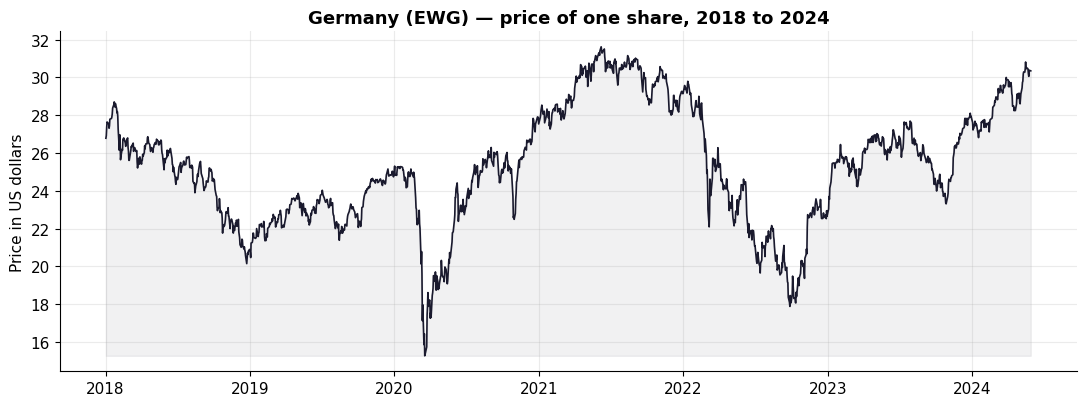

In [4]:
fig, ax = plt.subplots()
ax.plot(prices.index, prices['EWG'], color=INK, linewidth=1.2)
ax.fill_between(prices.index, prices['EWG'], prices['EWG'].min(), color=INK, alpha=0.06)
ax.set_title('Germany (EWG) — price of one share, 2018 to 2024')
ax.set_ylabel('Price in US dollars')
plt.tight_layout(); plt.show()

The chart goes up and down, but the **price level itself is not comparable between countries**. One German share costs about \$30 and one Japanese share costs about \$60. A \$1 move means something completely different in each case.

So the first thing anyone does with price data is convert it to a **return** — the *percentage* change from one day to the next. That is comparable across countries, across time, and across price levels.

### Doing it by hand

Let's take five consecutive days and compute the return the way you would on paper.

In [5]:
demo = prices['EWG'].loc['2020-02-20':'2020-02-27']

tbl = pd.DataFrame({'Price today': demo})
tbl['Price yesterday'] = tbl['Price today'].shift(1)
tbl['Change in $']     = tbl['Price today'] - tbl['Price yesterday']
tbl['Simple return %']  = 100 * tbl['Change in $'] / tbl['Price yesterday']
tbl['Log return %']     = 100 * np.log(tbl['Price today'] / tbl['Price yesterday'])

tbl.index = tbl.index.date
tbl.round(3)

,Price today,Price yesterday,Change in $,Simple return %,Log return %
2020-02-20,24.852,NaN,NaN,NaN,NaN
2020-02-21,24.683,24.852,-0.169,-0.682,-0.684
2020-02-24,23.633,24.683,-1.050,-4.255,-4.349
2020-02-25,23.099,23.633,-0.534,-2.258,-2.284
2020-02-26,23.023,23.099,-0.076,-0.330,-0.331
2020-02-27,22.438,23.023,-0.584,-2.539,-2.571


Read the fourth column: on 2020-02-24 the German market fell about 4%. That is a bad day. Notice how much easier that is to interpret than "the price went from 29.51 to 28.32".

### Why there are two return columns

You may have noticed we computed the return **twice**, in two slightly different ways:

$$\text{simple return} = \frac{P_{\text{today}} - P_{\text{yesterday}}}{P_{\text{yesterday}}}
\qquad\qquad
\text{log return} = \ln\!\left(\frac{P_{\text{today}}}{P_{\text{yesterday}}}\right)$$

The numbers are almost identical for small daily moves (compare the last two columns above — they barely differ). But the log version has one property that matters enormously, and it is easiest to see with a deliberately extreme example.

In [6]:
# A stock that gains 50%, then loses 50%. Does it end up where it started?
p0, p1, p2 = 100.0, 150.0, 75.0

story = pd.DataFrame({
    'Day': ['Start', 'After +50%', 'After -50%'],
    'Price': [p0, p1, p2],
    'Simple return %': [np.nan, 100*(p1-p0)/p0, 100*(p2-p1)/p1],
    'Log return %':    [np.nan, 100*np.log(p1/p0), 100*np.log(p2/p1)],
})
display(story.round(2))

print(f"Simple returns add up to : {story['Simple return %'].sum():+.1f}%  "
      "-> suggests you broke even")
print(f"Log returns add up to    : {story['Log return %'].sum():+.1f}%  "
      "-> correctly says you LOST money")
print(f"\nReality check: you started at ${p0:.0f} and ended at ${p2:.0f}. "
      f"You lost {100*(p0-p2)/p0:.0f}%.")

,Day,Price,Simple return %,Log return %
0,Start,100.0,NaN,NaN
1,After +50%,150.0,50.0,40.55
2,After -50%,75.0,-50.0,-69.31


Simple returns add up to : +0.0%  -> suggests you broke even
Log returns add up to    : -28.8%  -> correctly says you LOST money

Reality check: you started at $100 and ended at $75. You lost 25%.


**This is the whole reason the thesis uses log returns.** Simple returns lie when you add them up: +50% followed by −50% adds to zero, but you have actually lost a quarter of your money. Log returns add up correctly. Every formula from here on uses them.

From now on, "return" means "log return", written $r_t$.

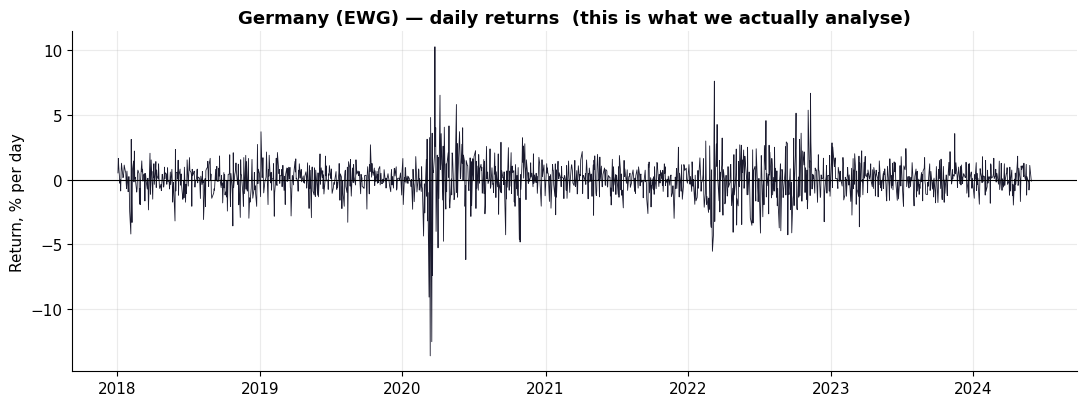

Average daily return : +0.0078%   (essentially zero)
Biggest single-day up move   : +10.22%
Biggest single-day down move : -13.57%


In [7]:
returns = np.log(prices / prices.shift(1)).dropna()

fig, ax = plt.subplots()
ax.plot(returns.index, 100*returns['EWG'], color=INK, linewidth=0.6)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Germany (EWG) — daily returns  (this is what we actually analyse)')
ax.set_ylabel('Return, % per day')
plt.tight_layout(); plt.show()

print(f"Average daily return : {100*returns['EWG'].mean():+.4f}%   (essentially zero)")
print(f"Biggest single-day up move   : {100*returns['EWG'].max():+.2f}%")
print(f"Biggest single-day down move : {100*returns['EWG'].min():+.2f}%")

Look carefully at that chart. Two things should jump out:

1. It hovers around zero and looks like random noise. **Which way it goes tomorrow is basically unpredictable** — if it weren't, someone would already have made the trade.
2. **The width of the band changes over time.** There is a violent explosion in early 2020, and calm stretches elsewhere.

Point 1 is why the thesis does *not* try to predict direction. Point 2 is the entire subject of the thesis. That changing width has a name: **volatility**.

---

## Part 2 — What volatility actually is

Volatility is the answer to: **"how big are the daily moves, regardless of direction?"**

It is *not* about going up or down. It is about the size of the bumps. The clearest way to see this is with two invented investments that **start and end at exactly the same price** but get there completely differently.

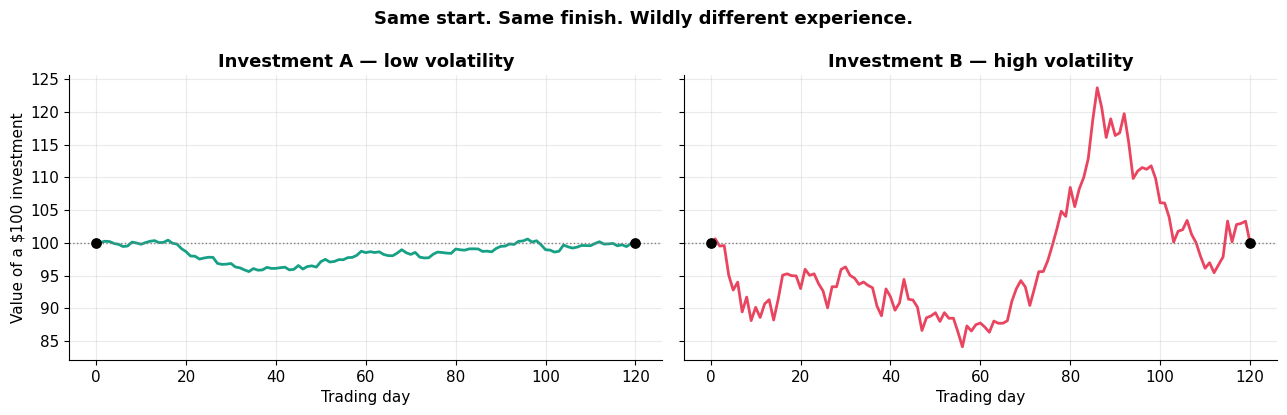

Both start at $100.00 and end at $100.00.
A's worst single day: -0.95%     B's worst single day: -4.94%
A's biggest drop from a peak: -4.8%
B's biggest drop from a peak: -22.8%


In [8]:
rng = np.random.default_rng(7)
days = np.arange(121)

calm_r  = rng.normal(0, 0.004, 120)   # small daily wobbles
wild_r  = rng.normal(0, 0.025, 120)   # big daily wobbles
# force both to end at exactly the same place, so ONLY the path differs
calm_r -= calm_r.mean(); wild_r -= wild_r.mean()
calm = 100*np.exp(np.r_[0, np.cumsum(calm_r)])
wild = 100*np.exp(np.r_[0, np.cumsum(wild_r)])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
a1.plot(days, calm, color=CALM, linewidth=2); a1.set_title('Investment A — low volatility')
a2.plot(days, wild, color=ACCENT, linewidth=2); a2.set_title('Investment B — high volatility')
for a in (a1, a2):
    a.scatter([0, 120], [100, calm[-1]], color='black', zorder=5, s=45)
    a.set_xlabel('Trading day'); a.axhline(100, color='grey', ls=':', linewidth=1)
a1.set_ylabel('Value of a $100 investment')
plt.suptitle('Same start. Same finish. Wildly different experience.',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Both start at $100.00 and end at ${calm[-1]:.2f}.")
print(f"A's worst single day: {100*calm_r.min():+.2f}%     B's worst single day: {100*wild_r.min():+.2f}%")
print(f"A's biggest drop from a peak: {100*(calm/np.maximum.accumulate(calm)-1).min():.1f}%")
print(f"B's biggest drop from a peak: {100*(wild/np.maximum.accumulate(wild)-1).min():.1f}%")

A simple return-based scorecard would call these two investments **identical** — same start, same finish, same total profit.

But nobody would call them the same. Investment B could have forced you to sell at a terrible moment, would have kept you awake at night, and if you had been borrowing money to buy it, your broker could have shut your position down at the bottom.

**Volatility is the number that tells these two apart.** It is the measure of "how rough was the ride" — and in finance, it *is* the working definition of risk.

---

## Part 3 — Computing volatility, step by step

We now build **Realized Volatility (RV)** from scratch. The full formula looks like this:

$$RV_t = \sqrt{\frac{1}{20}\sum_{i=1}^{20}\left(100\, r_{t-i}\right)^2}$$

That is intimidating written down, and completely mundane once you see it as a table. It is **four steps**, and you already know all four:

| Step | What you do | Why |
|---|---|---|
| 1 | Take the last 20 daily returns | One trading month of recent history |
| 2 | **Square** each one | Turns every move positive, so up and down both count as "movement" |
| 3 | **Average** the squares | One number summarising the typical squared move |
| 4 | Take the **square root** | Undoes the squaring, putting the answer back into readable "% per day" |

Let's do it on real numbers.

In [9]:
window = returns['EWG'].loc['2020-02-03':'2020-02-28'].head(20)

steps = pd.DataFrame({'Return r (%)': 100*window})
steps['STEP 2: squared'] = steps['Return r (%)']**2
steps.index = steps.index.date
display(steps.round(4))

mean_sq = steps['STEP 2: squared'].mean()
rv_val  = np.sqrt(mean_sq)

print(f"STEP 3  average of the squared column = {mean_sq:.4f}")
print(f"STEP 4  square root of that           = {rv_val:.4f}")
print()
print(f">>> Realized Volatility = {rv_val:.2f}% per day")
print()
print(f"    Plain English: over this month, a typical day for the German market")
print(f"    moved about {rv_val:.2f}% in one direction or the other.")

,Return r (%),STEP 2: squared
2020-02-03,0.2101,0.0441
2020-02-04,1.7681,3.1263
2020-02-05,1.1276,1.2716
2020-02-06,0.3054,0.0932
2020-02-07,-0.9531,0.9083
2020-02-10,0.0000,0.0000
2020-02-11,0.8175,0.6682
2020-02-12,0.7435,0.5528
2020-02-13,-0.8114,0.6583
2020-02-14,0.0679,0.0046


STEP 3  average of the squared column = 2.2006
STEP 4  square root of that           = 1.4834

>>> Realized Volatility = 1.48% per day

    Plain English: over this month, a typical day for the German market
    moved about 1.48% in one direction or the other.


### Two natural questions

**"Why square the returns instead of just ignoring the minus signs?"**

You could use absolute values, and some researchers do. Squaring is preferred for two reasons: it is smooth (which matters when a computer optimises a model), and it gives extra weight to large moves. A −6% day is not merely twice as alarming as a −3% day, and squaring encodes that: it counts for *four* times as much.

**"Why take the square root at the end?"**

Because without it the number is in unreadable units of "percent squared". The square root puts it back into plain percent, so you can compare it directly against an actual daily return. Squaring and then square-rooting is exactly how the everyday idea of a "typical size" works — it is the same operation behind the standard deviation.

### The rolling window

We don't compute RV once. We recompute it **every single day**, always using the most recent 20 days. The window slides forward one day at a time, like a 20-day-wide moving spotlight.

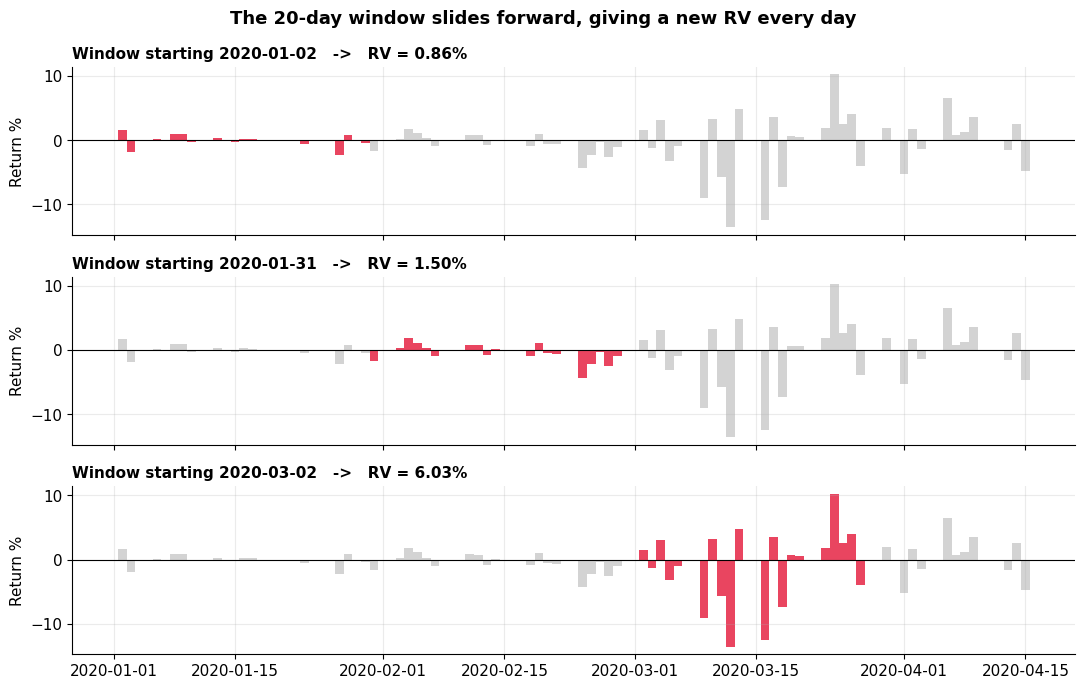

In [10]:
seg = 100*returns['EWG'].loc['2020-01-02':'2020-04-15']
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True, sharey=True)
starts = [0, 20, 40]

for ax, s in zip(axes, starts):
    ax.bar(seg.index, seg.values, color='lightgrey', width=1.0)
    win = seg.iloc[s:s+20]
    ax.bar(win.index, win.values, color=ACCENT, width=1.0)
    rvw = np.sqrt((win**2).mean())
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Window starting {win.index[0].date()}   ->   RV = {rvw:.2f}%',
                 loc='left', fontsize=11)
    ax.set_ylabel('Return %')

plt.suptitle('The 20-day window slides forward, giving a new RV every day',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

Notice the third panel: the same 20-day recipe, applied a month later, gives a far bigger number — because it now contains the COVID crash. **The recipe never changes; the answer changes because the world changed.** That is exactly what we want from a risk measure.

Now let's apply it to all ten countries at once. This single line does what we just did by hand, for every day and every country.

In [11]:
rv = (100*returns).pow(2).rolling(20).mean().pow(0.5).dropna()

print(f"Realized volatility computed: {rv.shape[0]:,} days x {rv.shape[1]} countries\n")
print("Most recent five days (numbers are '% move on a typical day'):")
display(rv[TICKERS].tail().round(3))

print("\nTypical (median) volatility over the whole period, by country:")
display(rv[TICKERS].median().sort_values(ascending=False).round(3).to_frame('RV %'))

Realized volatility computed: 1,591 days x 10 countries

Most recent five days (numbers are '% move on a typical day'):


Ticker,EWA,EWC,EWG,EWJ,EWT,EWU,EWW,EWY,EWZ,EZA
Date,,,,,,,,,,
2024-05-21,0.969,0.741,0.800,0.951,1.106,0.613,1.127,1.004,1.121,1.287
2024-05-22,1.053,0.740,0.814,0.981,1.124,0.636,1.104,1.008,1.187,1.378
2024-05-23,1.052,0.764,0.817,0.922,1.124,0.640,1.146,1.030,1.192,1.452
2024-05-24,1.061,0.795,0.830,0.934,1.127,0.634,1.107,1.021,1.081,1.347
2024-05-28,1.046,0.796,0.830,0.921,1.093,0.642,1.118,1.016,1.071,1.217



Typical (median) volatility over the whole period, by country:


,RV %
Ticker,
EWZ,1.838
EZA,1.738
EWY,1.373
EWW,1.313
EWT,1.124
EWA,1.095
EWG,1.036
EWC,0.952
EWJ,0.941


That ranking is a sanity check, and it passes: emerging markets (Brazil, South Africa, South Korea) sit at the top, developed markets (Japan, UK, Canada) at the bottom. This matches what any finance textbook would tell you, which is reassuring — our from-scratch calculation is measuring the real thing.

---

## Part 4 — What volatility looks like over time

Here is the whole story in one chart.

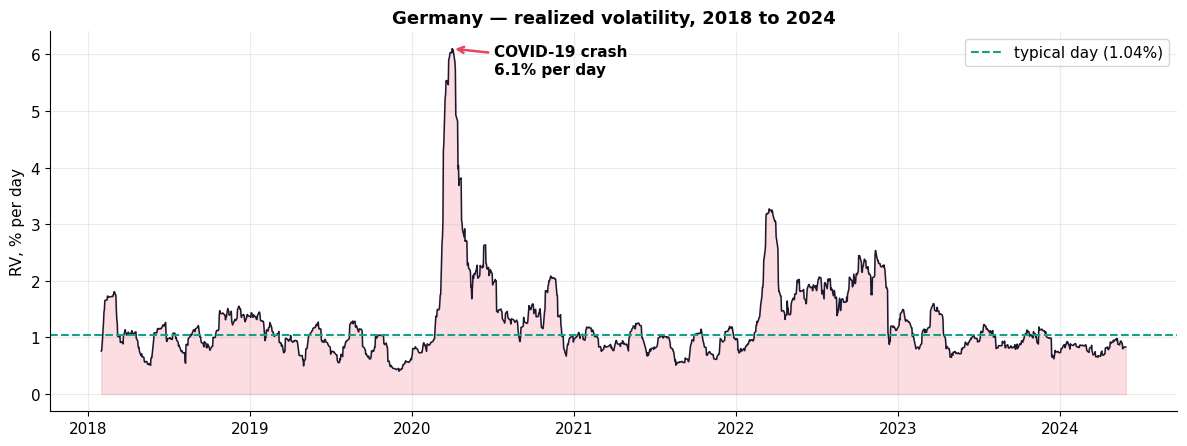

Calmest month on record : 0.40%  (2019-12-03)
Wildest month on record : 6.10%  (2020-04-01)
The wildest period was 15x more volatile than the calmest.


In [12]:
fig, ax = plt.subplots(figsize=(12, 4.6))
ax.plot(rv.index, rv['EWG'], color=INK, linewidth=1.1)
ax.fill_between(rv.index, rv['EWG'], color=ACCENT, alpha=0.18)

peak = rv['EWG'].idxmax()
ax.annotate(f'COVID-19 crash\n{rv["EWG"].max():.1f}% per day',
            xy=(peak, rv['EWG'].max()), xytext=(30, -18),
            textcoords='offset points', fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=ACCENT, linewidth=1.8))
ax.axhline(rv['EWG'].median(), color=CALM, ls='--', linewidth=1.5,
           label=f'typical day ({rv["EWG"].median():.2f}%)')
ax.set_title('Germany — realized volatility, 2018 to 2024')
ax.set_ylabel('RV, % per day'); ax.legend()
plt.tight_layout(); plt.show()

print(f"Calmest month on record : {rv['EWG'].min():.2f}%  ({rv['EWG'].idxmin().date()})")
print(f"Wildest month on record : {rv['EWG'].max():.2f}%  ({peak.date()})")
print(f"The wildest period was {rv['EWG'].max()/rv['EWG'].min():.0f}x more volatile than the calmest.")

A **17-fold** difference between the calmest and wildest periods. This is the single most important fact in the whole notebook:

> Risk is not a fixed property of a market. It moves, enormously, over time.

Any system that treats risk as a constant will be catastrophically wrong roughly once a decade. That is what makes forecasting volatility worth doing.

---

## Part 5 — The reason forecasting is possible at all

We established in Part 1 that the *direction* of returns is unpredictable. So why should the *volatility* be any different?

Because of an empirical fact called **volatility clustering**, first noted by Benoit Mandelbrot in 1963:

> *"Large changes tend to be followed by large changes, of either sign, and small changes tend to be followed by small changes."*

Calm days cluster with calm days; wild days cluster with wild days. Storms have a duration. Let's prove this actually holds in our data rather than just asserting it.

,DIRECTION (returns),SIZE OF MOVES (RV)
Days into the past,,
1,-0.052,0.991
5,0.064,0.927
10,-0.045,0.801
20,-0.057,0.497
40,0.014,0.277
60,-0.037,0.193


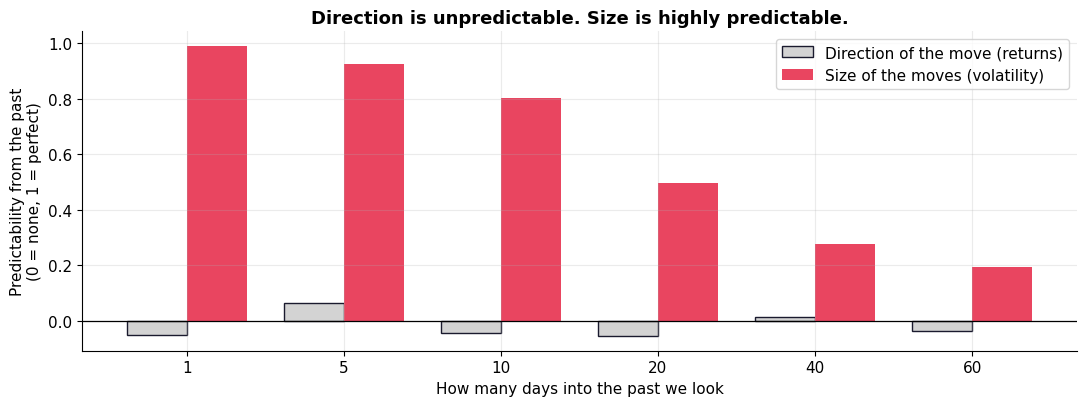

In [13]:
def autocorrelation(series, lag):
    """How similar is the series to itself, shifted `lag` days?
    +1 = perfectly predictable from the past, 0 = no relationship at all."""
    s = pd.Series(series).dropna()
    return s.corr(s.shift(lag))

lags = [1, 5, 10, 20, 40, 60]
comparison = pd.DataFrame({
    'Days into the past':      lags,
    'DIRECTION (returns)':     [autocorrelation(returns['EWG'], L)   for L in lags],
    'SIZE OF MOVES (RV)':      [autocorrelation(rv['EWG'], L)        for L in lags],
}).set_index('Days into the past')

display(comparison.round(3))

fig, ax = plt.subplots(figsize=(11, 4.2))
w = 0.38; xp = np.arange(len(lags))
ax.bar(xp - w/2, comparison['DIRECTION (returns)'], w, color='lightgrey',
       edgecolor=INK, label='Direction of the move (returns)')
ax.bar(xp + w/2, comparison['SIZE OF MOVES (RV)'], w, color=ACCENT,
       label='Size of the moves (volatility)')
ax.axhline(0, color='black', linewidth=0.9)
ax.set_xticks(xp); ax.set_xticklabels(lags)
ax.set_xlabel('How many days into the past we look')
ax.set_ylabel('Predictability from the past\n(0 = none, 1 = perfect)')
ax.set_title('Direction is unpredictable. Size is highly predictable.')
ax.legend()
plt.tight_layout(); plt.show()

The grey bars sit at essentially zero: **knowing yesterday's direction tells you nothing about today's direction.** That is efficient markets doing their job.

The red bars are enormous — around 0.9 at one day, and still meaningfully positive two months later. **Knowing yesterday's volatility tells you a great deal about today's volatility.**

This gap is the licence for the whole thesis. We are not trying to beat the market on direction, which is close to impossible. We are forecasting the *size* of moves, which is genuinely forecastable — and which is what risk managers, option traders and regulators actually need.

### So what exactly is being predicted?

Precisely this:

> Given everything known up to and including today (day $t$), predict **$RV_{t+1}$** — the realized volatility for tomorrow — for each of the 10 countries.

One number per country, one day ahead. That is the whole task.

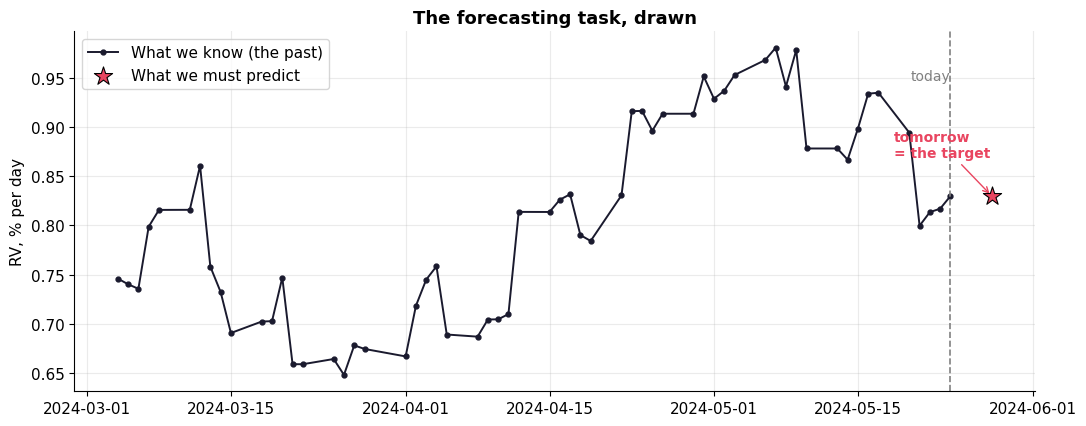

In [14]:
recent = rv['EWG'].tail(60)
fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(recent.index[:-1], recent.values[:-1], color=INK, marker='o', markersize=3.5,
        linewidth=1.4, label='What we know (the past)')
ax.scatter(recent.index[-1], recent.values[-1], s=190, color=ACCENT, zorder=5,
           marker='*', edgecolor='black', linewidth=0.8, label='What we must predict')
ax.axvline(recent.index[-2], color='grey', ls='--', linewidth=1.2)
ax.annotate('today', xy=(recent.index[-2], ax.get_ylim()[1]*0.95), fontsize=10,
            ha='right', color='grey')
ax.annotate('tomorrow\n= the target', xy=(recent.index[-1], recent.values[-1]),
            xytext=(-70, 28), textcoords='offset points', fontsize=10,
            fontweight='bold', color=ACCENT,
            arrowprops=dict(arrowstyle='->', color=ACCENT))
ax.set_title('The forecasting task, drawn')
ax.set_ylabel('RV, % per day'); ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

---

## Part 6 — Why anyone cares: a worked example

Suppose you manage a \$10,000,000 fund invested in the German market. Your regulator requires you to state, every single day: *"with 99% confidence, we will not lose more than X tomorrow."* That number X is called **Value-at-Risk**, and it is a legal requirement, not an academic exercise.

The rough recipe is `Value-at-Risk ≈ 2.33 × volatility × portfolio value`. Everything hinges on which volatility you put in.

In [15]:
PORTFOLIO = 10_000_000
Z99 = 2.33   # the 99% confidence multiplier

scenarios = pd.DataFrame({
    'Scenario': ['Calm period', 'Normal period', 'COVID crash'],
    'RV, % per day': [rv['EWG'].quantile(0.05), rv['EWG'].median(), rv['EWG'].max()],
})
scenarios['Value-at-Risk ($)'] = (Z99 * scenarios['RV, % per day']/100 * PORTFOLIO)
scenarios['Cash you must hold'] = scenarios['Value-at-Risk ($)'].map('${:,.0f}'.format)
display(scenarios.round(3))

calm_var  = scenarios.loc[0, 'Value-at-Risk ($)']
covid_var = scenarios.loc[2, 'Value-at-Risk ($)']

print(f"If you assume calm conditions but a crisis actually arrives, you have set")
print(f"aside ${calm_var:,.0f} against a real risk of ${covid_var:,.0f}.")
print(f"You are under-reserved by a factor of {covid_var/calm_var:.0f}x.")
print()
print("That is not a rounding error. That is how firms fail.")

,Scenario,"RV, % per day",Value-at-Risk ($),Cash you must hold
0,Calm period,0.616,1.4353e+05,"$143,526"
1,Normal period,1.036,2.4146e+05,"$241,457"
2,COVID crash,6.101,1.4214e+06,"$1,421,441"


If you assume calm conditions but a crisis actually arrives, you have set
aside $143,526 against a real risk of $1,421,441.
You are under-reserved by a factor of 10x.

That is not a rounding error. That is how firms fail.


This is the practical stake. Getting tomorrow's volatility badly wrong — **especially when a crisis is starting** — is how institutions blow up. A forecast that reacts faster when trouble arrives is worth real money, which is why the thesis pays such close attention to crisis periods specifically.

---

## Part 7 — Countries do not move alone

Everything so far treated Germany in isolation. But markets are connected: when Wall Street has a bad night, Tokyo opens lower.

Let's look at March 2020, when every market on earth moved together.

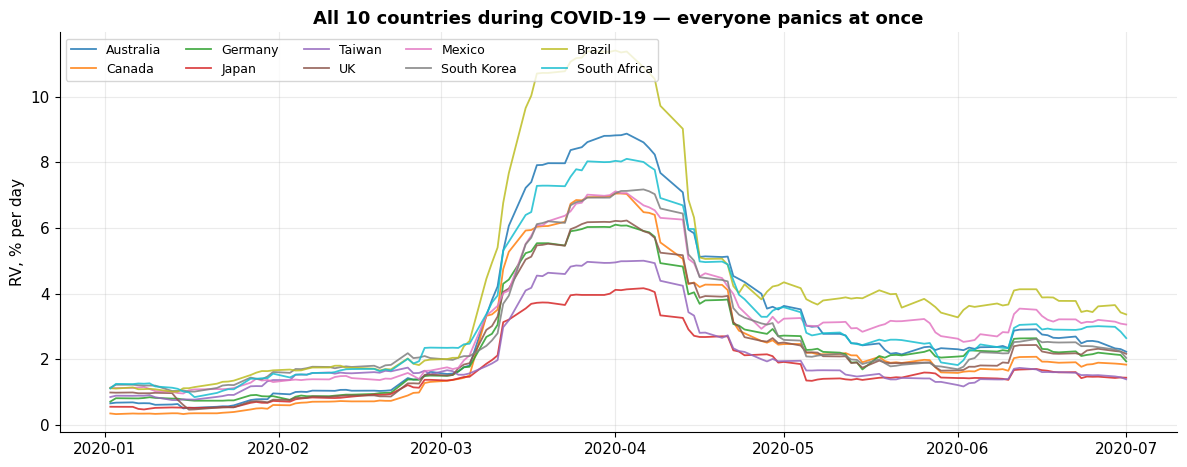

In [16]:
covid = rv.loc['2020-01-01':'2020-07-01', TICKERS]
fig, ax = plt.subplots(figsize=(12, 4.8))
for t in TICKERS:
    ax.plot(covid.index, covid[t], linewidth=1.3, alpha=0.85, label=COUNTRY[t])
ax.set_title('All 10 countries during COVID-19 — everyone panics at once')
ax.set_ylabel('RV, % per day')
ax.legend(ncol=5, fontsize=9, loc='upper left')
plt.tight_layout(); plt.show()

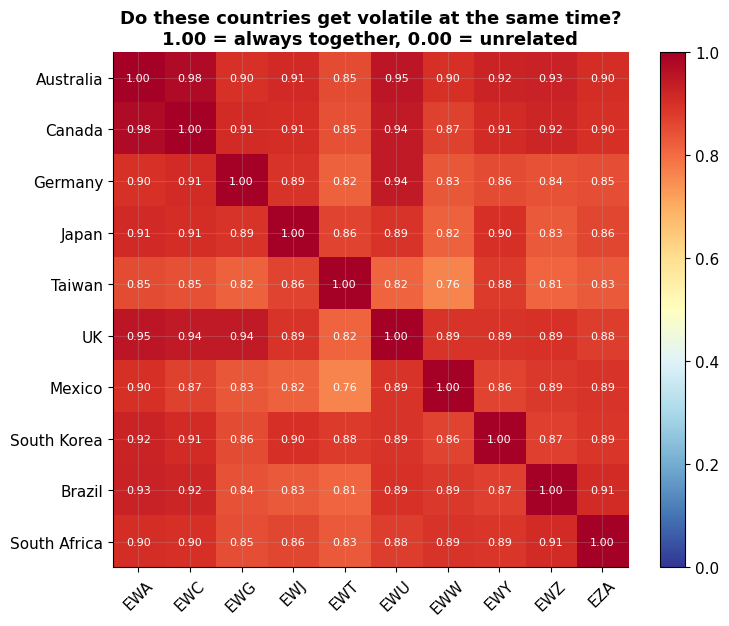

Average correlation between two different countries: 0.88
Well above zero -> volatility is a global phenomenon, not a local one.


In [17]:
corr = rv[TICKERS].corr()
fig, ax = plt.subplots(figsize=(7.6, 6.4))
im = ax.imshow(corr, cmap='RdYlBu_r', vmin=0, vmax=1)
ax.set_xticks(range(10)); ax.set_xticklabels(TICKERS, rotation=45)
ax.set_yticks(range(10)); ax.set_yticklabels([COUNTRY[t] for t in TICKERS])
for i in range(10):
    for j in range(10):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='white' if corr.iloc[i,j] > 0.65 else 'black')
ax.set_title('Do these countries get volatile at the same time?\n1.00 = always together, 0.00 = unrelated')
plt.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()

off = corr.values[~np.eye(10, dtype=bool)]
print(f"Average correlation between two different countries: {off.mean():.2f}")
print("Well above zero -> volatility is a global phenomenon, not a local one.")

### What correlation cannot tell you

Correlation says Germany and Brazil get nervous **at the same time**. It does not say *who goes first*. Correlation is symmetric: the correlation of Germany with Brazil is identical to Brazil with Germany, by construction.

But for forecasting, direction is everything. "Germany moves first, Brazil follows" is a usable trading signal. "They wobble together" is not.

To capture direction we need a different tool, and that tool is **transfer entropy**.

---

## Part 8 — Transfer entropy, without the mathematics

Here is the whole idea, in one thought experiment.

**Step 1.** Try to guess tomorrow's Brazil, using **only Brazil's own history**. You will make some amount of error. Call it *Error A*.

**Step 2.** Now try again, using **Brazil's history *and* Germany's history**. Call the new error *Error B*.

**Step 3.** If Error B is smaller than Error A, then Germany's past contained genuinely useful information about Brazil's future — information that was *not already* in Brazil's own past.

> **Transfer entropy is the size of that improvement.**

That is it. It is a measure of "how much did knowing about Germany help me predict Brazil, over and above what I already knew from Brazil itself."

Three properties make it the right tool here:

| Property | Why it matters |
|---|---|
| It is **directional** | Germany→Brazil and Brazil→Germany are separate numbers. Correlation cannot do this. |
| It catches **non-straight-line** relationships | Correlation only sees straight lines. Crises are not straight lines. |
| It measures **new** information | It automatically ignores anything Brazil's own past already told us. |

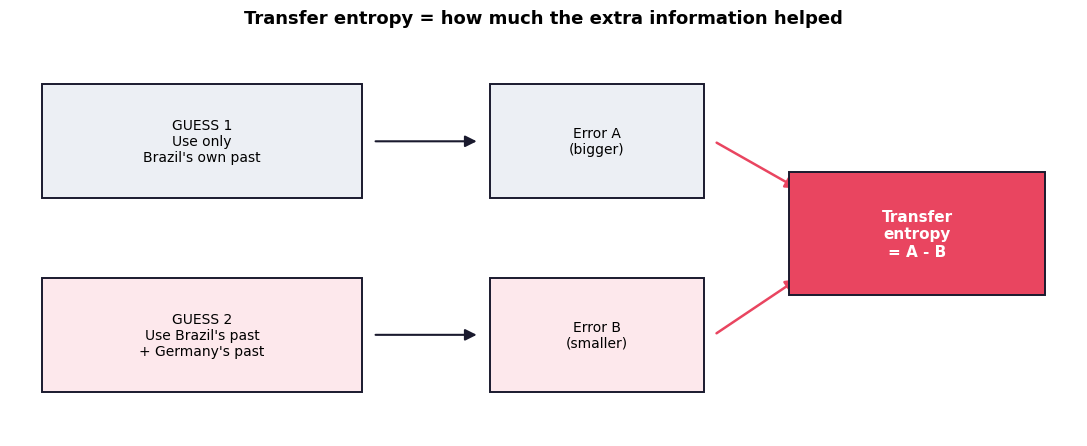

In [18]:
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.axis('off'); ax.set_xlim(0, 10); ax.set_ylim(0, 4.6)

def box(x, y, w, h, txt, fc, tc='black', fs=10, weight='normal'):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=INK,
                               linewidth=1.4, zorder=2))
    ax.text(x + w/2, y + h/2, txt, ha='center', va='center', fontsize=fs,
            color=tc, fontweight=weight, zorder=3)

box(0.3, 2.7, 3.0, 1.3, "GUESS 1\nUse only\nBrazil's own past", '#eceff4')
box(0.3, 0.5, 3.0, 1.3, "GUESS 2\nUse Brazil's past\n+ Germany's past", '#fde8ec')
box(4.5, 2.7, 2.0, 1.3, "Error A\n(bigger)", '#eceff4')
box(4.5, 0.5, 2.0, 1.3, "Error B\n(smaller)", '#fde8ec')
box(7.3, 1.6, 2.4, 1.4, "Transfer\nentropy\n= A - B", ACCENT, 'white', 11, 'bold')

for y in (3.35, 1.15):
    ax.add_patch(FancyArrowPatch((3.4, y), (4.4, y), arrowstyle='-|>',
                                 mutation_scale=17, color=INK, linewidth=1.5))
ax.add_patch(FancyArrowPatch((6.6, 3.35), (7.4, 2.8), arrowstyle='-|>',
                             mutation_scale=17, color=ACCENT, linewidth=1.8))
ax.add_patch(FancyArrowPatch((6.6, 1.15), (7.4, 1.8), arrowstyle='-|>',
                             mutation_scale=17, color=ACCENT, linewidth=1.8))
ax.set_title('Transfer entropy = how much the extra information helped',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### From transfer entropy to a graph

Compute that number for **every ordered pair** of the 10 countries — Germany→Brazil, Brazil→Germany, Japan→Taiwan, and so on, 90 pairs in total. Keep only the pairs where the improvement is big enough to be real rather than luck. What you are left with is a **network**.

A network (or *graph*) is just dots and arrows:
- each **dot** (a *node*) is a country
- each **arrow** (an *edge*) means "this country's past helps predict that country's future"
- a **thicker arrow** means more information flowing

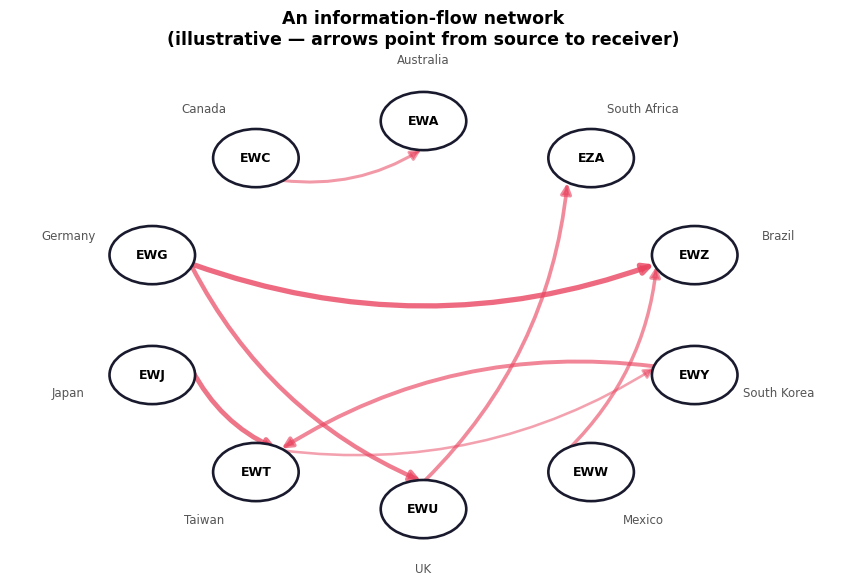

In [19]:
fig, ax = plt.subplots(figsize=(8.6, 6))
ax.axis('off'); ax.set_xlim(-1.45, 1.45); ax.set_ylim(-1.35, 1.35)

ang = np.linspace(0, 2*np.pi, 10, endpoint=False) + np.pi/2
pos = {t: (np.cos(a), np.sin(a)) for t, a in zip(TICKERS, ang)}

demo_edges = [('EWG','EWZ',0.9), ('EWG','EWU',0.7), ('EWJ','EWT',0.8),
              ('EWY','EWT',0.6), ('EWW','EWZ',0.5), ('EWC','EWA',0.4),
              ('EWU','EZA',0.55), ('EWT','EWY',0.3)]

for s, t, wgt in demo_edges:
    x1, y1 = pos[s]; x2, y2 = pos[t]
    ax.add_patch(FancyArrowPatch((x1*0.86, y1*0.86), (x2*0.86, y2*0.86),
                                 connectionstyle='arc3,rad=0.18', arrowstyle='-|>',
                                 mutation_scale=15, linewidth=0.9 + 3.2*wgt,
                                 color=ACCENT, alpha=0.35 + 0.5*wgt, zorder=1))
for t in TICKERS:
    x, y = pos[t]
    ax.add_patch(Circle((x, y), 0.15, facecolor='white', edgecolor=INK,
                        linewidth=1.9, zorder=3))
    ax.text(x, y, t, ha='center', va='center', fontsize=9, fontweight='bold', zorder=4)
    ax.text(x*1.31, y*1.31, COUNTRY[t], ha='center', va='center', fontsize=8.5,
            color='#555')

ax.set_title('An information-flow network\n(illustrative — arrows point from source to receiver)',
             fontsize=12.5, fontweight='bold')
plt.tight_layout(); plt.show()

This network is what gets fed to the **Graph Neural Network** in the main thesis. In plain terms, the model forecasts each country's volatility while *listening to the countries that the arrows say are worth listening to*. Brazil's forecast pays attention to Germany, because the data said Germany leads Brazil — and it ignores countries with no arrow pointing in.

That is what makes this a *graph* neural network rather than an ordinary one: the network structure is not guessed, it is **measured from the data**.

---

## Part 9 — The two remaining pieces of the title

The thesis is called **HR-ETE-GNN**: *Hurst-Regime adaptive, Effective Transfer Entropy, Graph Neural Network*. We have now covered the ETE and the GNN. Two ideas remain.

### The Rényi parameter $\alpha$ — a "tail sensitivity" dial

Ordinary transfer entropy treats every day as equally important. A sleepy Tuesday and a market crash both count the same when the average is taken.

That is a strange choice for a thesis about crises. **Rényi** transfer entropy adds a tuning dial, $\alpha$:

| Setting | Effect | Best for |
|---|---|---|
| $\alpha < 1$ | Amplifies **rare, extreme** days | Crashes and panics |
| $\alpha = 1$ | Everything counts equally (this is ordinary transfer entropy) | The neutral default |
| $\alpha > 1$ | Amplifies **ordinary, typical** days | Calm markets |

Think of it as a camera exposure setting. Turn it one way and the bright ordinary scene is properly exposed; turn it the other way and you can finally see detail in the dark corners. The rare crash days *are* the dark corners — and they are precisely the days a risk manager cares about.

**The thesis hypothesis:** during crises, setting $\alpha < 1$ should reveal spillover connections that ordinary transfer entropy misses entirely.

### The Hurst exponent — a calm-or-turbulent detector

The last piece answers: *how do we know a crisis is happening, without waiting to be told?*

The **Hurst exponent** $H$ is a single number describing a market's character:

| Value | Name | What it means day to day |
|---|---|---|
| $H > 0.5$ | *persistent* | Trends continue. Up days follow up days. Calm, orderly markets. |
| $H \approx 0.5$ | *random walk* | Yesterday says nothing about today. |
| $H < 0.5$ | *anti-persistent* | Violent reversals. Up 3%, down 4%, up 2%. Panic. |

The thesis computes $H$ on a rolling basis, and uses it as an automatic regime switch: when $H$ drops below 0.5, the market has entered a turbulent state, and the model adapts by dialling $\alpha$ towards the tail-sensitive setting.

That is where the **"Hurst-Regime adaptive"** in the title comes from. Let's see it on real data.

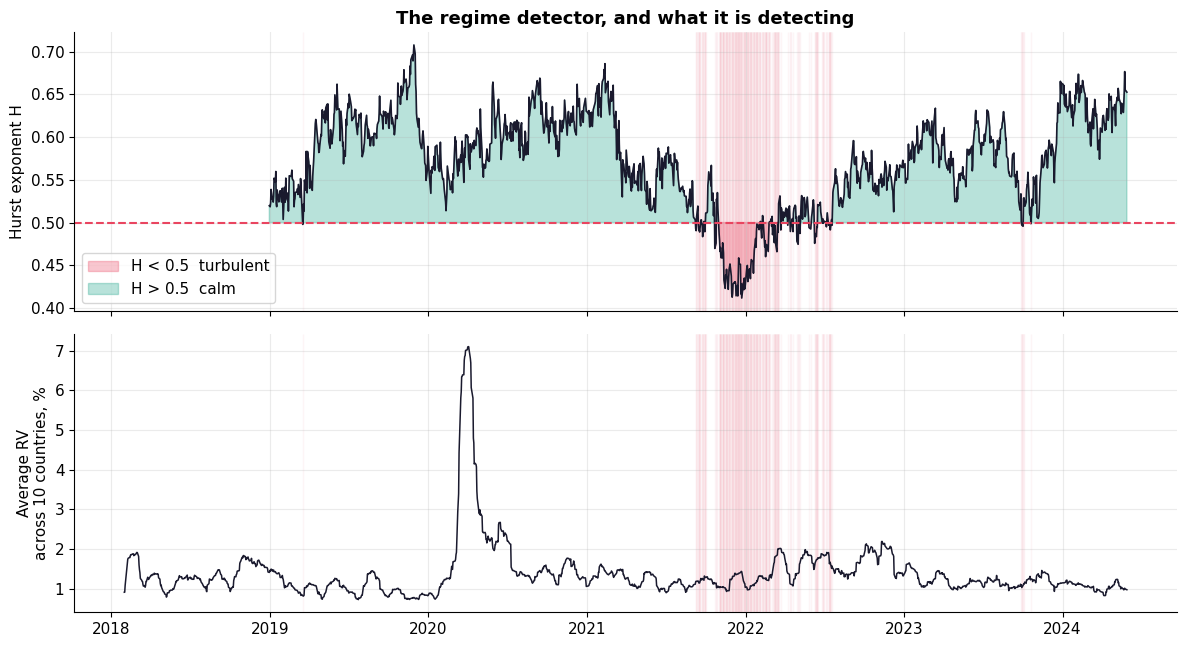

Turbulent days (H < 0.5): 130 of 1,361  (9.6%)


In [20]:
def hurst_rs(series):
    """Rescaled-range estimate of the Hurst exponent."""
    s = np.asarray(series, float); N = len(s)
    if N < 20: return np.nan
    out = []
    for lag in np.unique(np.logspace(1, np.log10(N//2), 10).astype(int)):
        vals = []
        for j in range(N//lag):
            seg = s[j*lag:(j+1)*lag]
            dev = np.cumsum(seg - seg.mean())
            sd = seg.std(ddof=1)
            if sd > 0: vals.append((dev.max() - dev.min())/sd)
        if vals: out.append((lag, np.mean(vals)))
    if len(out) < 2: return np.nan
    L, R = zip(*out)
    return np.polyfit(np.log(L), np.log(R), 1)[0]

world = yf.download('URTH', start='2018-01-01', end='2024-05-29',
                    auto_adjust=True, progress=False)['Close'].dropna()
world_ret = np.log(world/world.shift(1)).dropna().squeeze()
hurst = world_ret.rolling(250).apply(hurst_rs, raw=True).dropna()

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 6.6), sharex=True)
a1.plot(hurst.index, hurst.values, color=INK, linewidth=1.2)
a1.axhline(0.5, color=ACCENT, ls='--', linewidth=1.5)
a1.fill_between(hurst.index, hurst.values, 0.5, where=(hurst.values < 0.5),
                color=ACCENT, alpha=0.3, label='H < 0.5  turbulent')
a1.fill_between(hurst.index, hurst.values, 0.5, where=(hurst.values >= 0.5),
                color=CALM, alpha=0.3, label='H > 0.5  calm')
a1.set_ylabel('Hurst exponent H'); a1.legend(loc='lower left')
a1.set_title('The regime detector, and what it is detecting')

a2.plot(rv.index, rv[TICKERS].mean(axis=1), color=INK, linewidth=1.1)
a2.set_ylabel('Average RV\nacross 10 countries, %')
for ax in (a1, a2):
    for d in hurst.index[hurst.values < 0.5]:
        ax.axvspan(d, d + pd.Timedelta(days=1), color=ACCENT, alpha=0.05, zorder=0)
plt.tight_layout(); plt.show()

n_turb = int((hurst < 0.5).sum())
print(f"Turbulent days (H < 0.5): {n_turb:,} of {len(hurst):,}  ({100*n_turb/len(hurst):.1f}%)")

The shaded bands in the top panel mark the turbulent regime, and the bottom panel shows they line up with the periods when volatility across all ten countries was actually elevated. The detector is detecting something real.

Note the last line of output, though: turbulent days are a **small minority** of the sample. That is worth remembering — the crisis periods this thesis is most interested in are also the periods where there is least data to learn from. It is the central difficulty of the whole exercise.

---

## Part 10 — Putting it all together

Every piece now has a place. Here is the complete pipeline, in order.

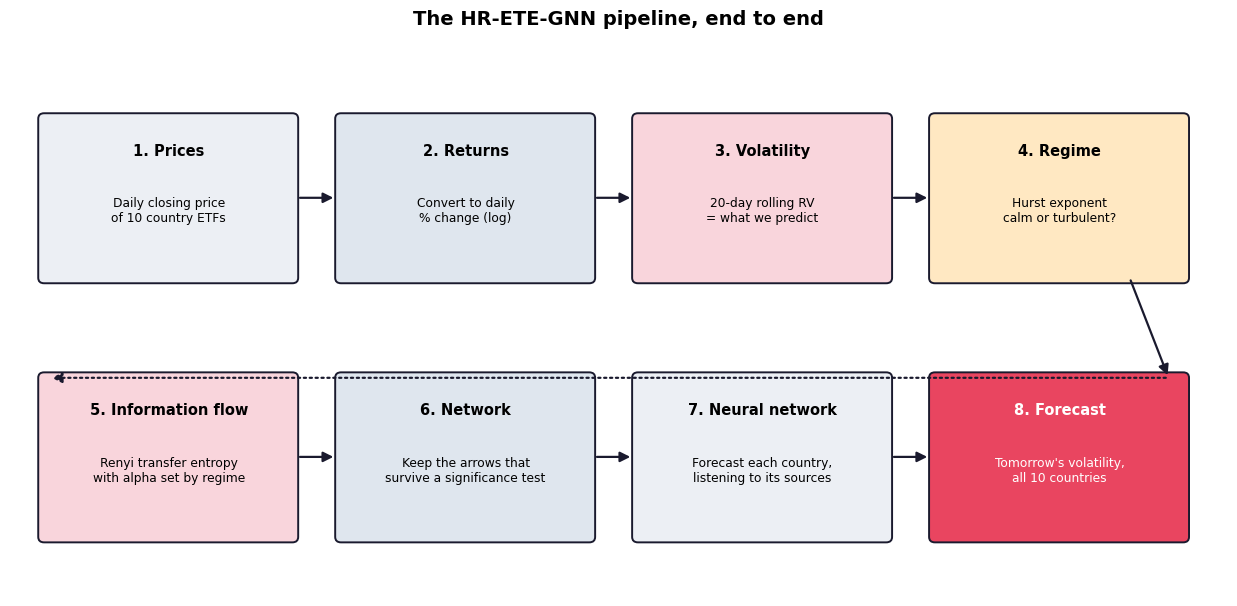

In [21]:
from matplotlib.patches import FancyBboxPatch

stages = [
    ("1. Prices",            "Daily closing price\nof 10 country ETFs",        '#eceff4'),
    ("2. Returns",           "Convert to daily\n% change (log)",               '#dfe6ee'),
    ("3. Volatility",        "20-day rolling RV\n= what we predict",           '#f9d5dc'),
    ("4. Regime",            "Hurst exponent\ncalm or turbulent?",             '#ffe8c2'),
    ("5. Information flow",  "Renyi transfer entropy\nwith alpha set by regime", '#f9d5dc'),
    ("6. Network",           "Keep the arrows that\nsurvive a significance test", '#dfe6ee'),
    ("7. Neural network",    "Forecast each country,\nlistening to its sources", '#eceff4'),
    ("8. Forecast",          "Tomorrow's volatility,\nall 10 countries",        ACCENT),
]

fig, ax = plt.subplots(figsize=(12.5, 6.2))
ax.axis('off'); ax.set_xlim(0, 12.5); ax.set_ylim(0, 6.2)

for i, (title, body, colr) in enumerate(stages):
    col, row = i % 4, i // 4
    x, y = 0.35 + col*3.05, 3.5 - row*2.85
    ax.add_patch(FancyBboxPatch((x, y), 2.55, 1.75, boxstyle='round,pad=0.06',
                                facecolor=colr, edgecolor=INK, linewidth=1.4))
    tc = 'white' if colr == ACCENT else 'black'
    ax.text(x + 1.28, y + 1.35, title, ha='center', fontsize=10.5,
            fontweight='bold', color=tc)
    ax.text(x + 1.28, y + 0.62, body, ha='center', fontsize=8.8, color=tc)
    if col < 3:
        ax.add_patch(FancyArrowPatch((x+2.6, y+0.88), (x+3.0, y+0.88),
                                     arrowstyle='-|>', mutation_scale=15,
                                     color=INK, linewidth=1.6))
ax.add_patch(FancyArrowPatch((11.5, 3.5), (11.9, 2.4), arrowstyle='-|>',
                             mutation_scale=15, color=INK, linewidth=1.6))
ax.add_patch(FancyArrowPatch((11.9, 2.4), (0.4, 2.4), arrowstyle='-|>',
                             mutation_scale=15, color=INK, linewidth=1.6,
                             connectionstyle='arc3,rad=0.0', linestyle=':'))
ax.set_title('The HR-ETE-GNN pipeline, end to end', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---

## Glossary

Everything defined in one place, in plain language.

In [22]:
glossary = pd.DataFrame([
 ("Return",              "The % change in price from one day to the next."),
 ("Log return",          "A return computed with logarithms, so that gains and losses add up honestly."),
 ("Volatility",          "How big the daily moves are, ignoring direction. Finance's word for risk."),
 ("Realized Volatility", "Volatility measured from actual past returns: square them, average, square-root."),
 ("Rolling window",      "Always using the most recent 20 days, sliding forward one day at a time."),
 ("Volatility clustering","Calm days follow calm days; wild days follow wild days. Why forecasting works."),
 ("Value-at-Risk",       "'We will not lose more than X tomorrow, with 99% confidence.'"),
 ("Correlation",         "Do two markets move together? Symmetric - cannot tell you who moves first."),
 ("Transfer entropy",    "How much country A's past improves a forecast of country B's future. Directional."),
 ("Effective TE",        "Transfer entropy with measurement bias subtracted off, so small values are trustworthy."),
 ("Renyi alpha",         "A dial: below 1 emphasises rare crash days, above 1 emphasises ordinary days."),
 ("Hurst exponent",      "One number saying whether a market is trending (H>0.5) or thrashing (H<0.5)."),
 ("Regime",              "Which state the market is in - calm or turbulent."),
 ("Graph / network",     "Dots joined by arrows. Here: countries joined by measured information flow."),
 ("Node / Edge",         "A dot (one country) / an arrow (information flowing from one country to another)."),
 ("GNN",                 "A neural network that forecasts each node while listening to its neighbours."),
 ("ETF",                 "One tradeable share holding a whole basket of stocks - a proxy for a whole market."),
], columns=['Term', 'In plain English'])

pd.set_option('display.max_colwidth', 100)
for _, row in glossary.iterrows():
    print(f"{row['Term']:<22}  {row['In plain English']}")

Return                  The % change in price from one day to the next.
Log return              A return computed with logarithms, so that gains and losses add up honestly.
Volatility              How big the daily moves are, ignoring direction. Finance's word for risk.
Realized Volatility     Volatility measured from actual past returns: square them, average, square-root.
Rolling window          Always using the most recent 20 days, sliding forward one day at a time.
Volatility clustering   Calm days follow calm days; wild days follow wild days. Why forecasting works.
Value-at-Risk           'We will not lose more than X tomorrow, with 99% confidence.'
Correlation             Do two markets move together? Symmetric - cannot tell you who moves first.
Transfer entropy        How much country A's past improves a forecast of country B's future. Directional.
Effective TE            Transfer entropy with measurement bias subtracted off, so small values are trustworthy.
Renyi alpha          

---

## What to take away

1. **Volatility is the size of market moves, not their direction.** It is the working definition of risk.
2. **Realized Volatility is four arithmetic steps** on the last 20 daily returns: square, average, square-root. Nothing more.
3. **Direction is unpredictable; size is predictable.** Volatility clusters, and that is what makes this thesis possible.
4. **Getting it wrong is expensive**, and most expensive exactly when a crisis begins.
5. **Countries are connected, and the connections have a direction.** Transfer entropy measures that direction; correlation cannot.
6. **The Rényi dial ($\alpha$) and the Hurst regime detector** are the thesis's two contributions: look harder at rare events, and know automatically when to start looking.

The companion notebook `HR_ETE_GNN_stats.ipynb` takes the next step: proving, with formal statistical tests, whether this actually forecasts better than the methods it is built on.